In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import svd, orth, qr
from smooth_POD_ROM.reduced_order_model import pulse, delta_n_width
from smooth_POD_ROM.pre_processing import smoothen

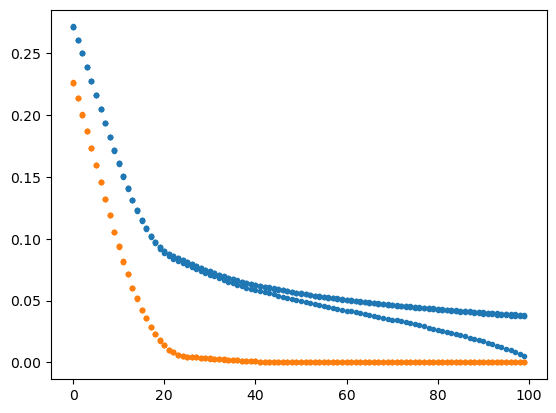

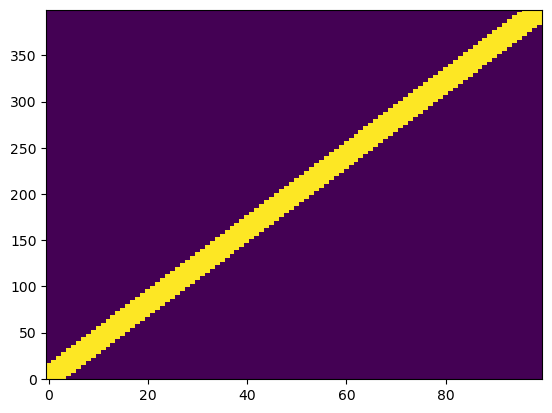

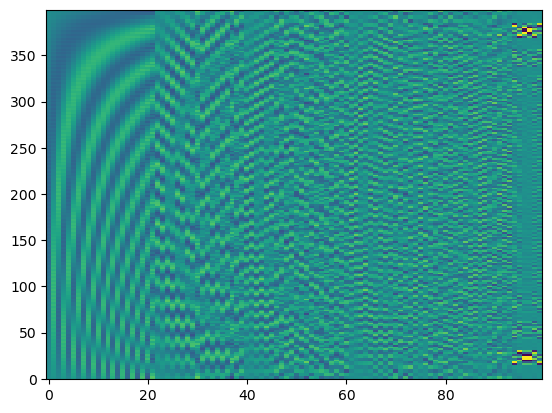

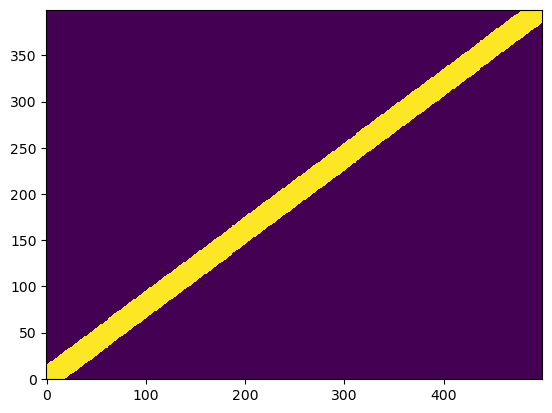

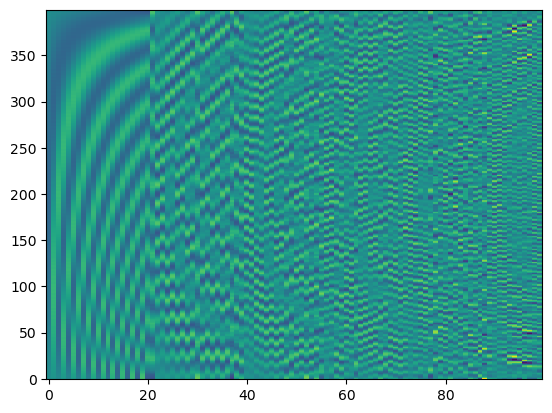

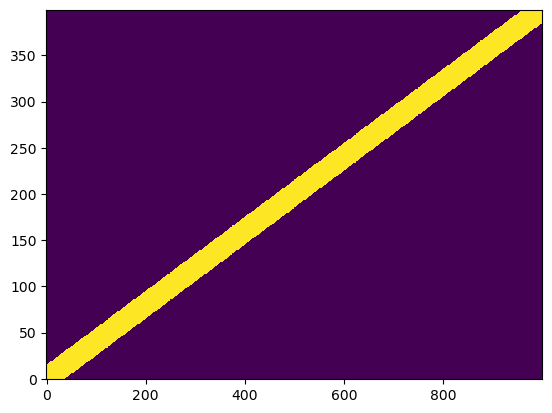

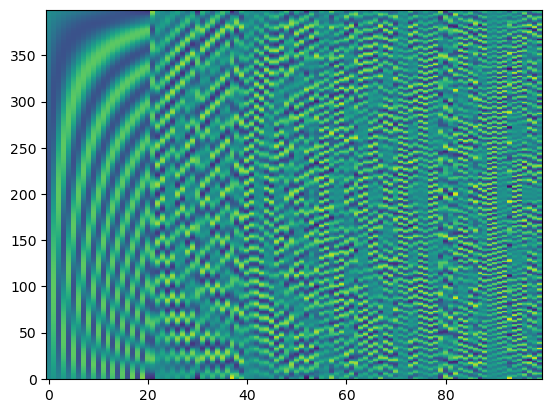

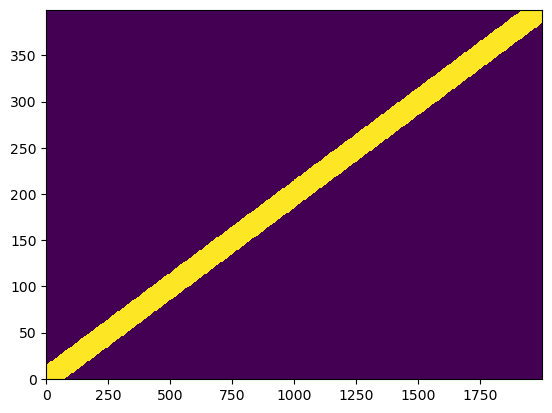

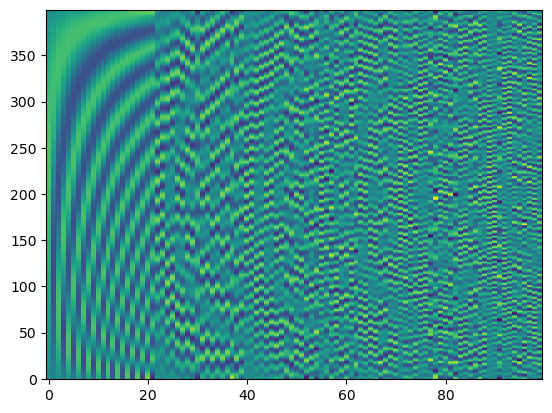

In [29]:
m, n = 400, 100
sigma = 0.02
dx = 1/m

x = np.linspace(0, 1, m, endpoint=False)+dx/2

fig, ax = plt.subplots()

for n in [100, 500, 1000, 2000]:
    mu_train = np.linspace(0.0, 1.0, n, endpoint=False)+1/(2*n)

    X_train = np.empty((m, n))

    for j, mu_j in enumerate(mu_train):
        X_train[:, j] = pulse(x, mu_j)
    X_train_s = smoothen(X_train, sigma/dx, x.shape, truncate=12)

    U, S, VT = np.linalg.svd(X_train, False)
    U_s, S_s, VT_s = np.linalg.svd(X_train_s, False)

    dN = delta_n_width(S, m, n)
    dN_S = delta_n_width(S_s, m, n)
    ax.plot(dN[:100], "C0.")
    ax.plot(dN_S[:100], "C1.")
    
    
    fig, ax2 = plt.subplots()
    ax2.imshow(X_train, origin="lower", interpolation="nearest")
    ax2.set_aspect("auto")
    
    
    fig, ax3 = plt.subplots()
    ax3.imshow(U[:, :100], origin="lower", interpolation="nearest")
    ax3.set_aspect("auto")
plt.show()